In [29]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
import json
import numpy as np
from types import SimpleNamespace
from pathlib import Path
from senn.trainer import SENN_Trainer

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "senn").is_dir():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise RuntimeError("Could not find project root containing 'senn'")
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [58]:
from senn.datasets.dataloaders import load_fashion_mnist
from senn.utils.MNIST_autoencoder import AETrainer, get_most_similar
from senn.trainer import init_trainer
from senn.utils.plot_utils import get_comparison_plot
from senn.utils.concept_representations import highest_activations, highest_contrast

## Load data

In [31]:
BATCH_SIZE = 200
_, _, test_loader = load_fashion_mnist("datasets/data/fashion_mnist_data", BATCH_SIZE)

In [32]:
ae_trainer = AETrainer(test_loader, BATCH_SIZE)
ae_trainer.load_model("senn/utils/FashionMNIST_autoencoder_pretrained.pt")

In [44]:
latents = ae_trainer.get_latent_reps(test_loader)
distances, indices = get_most_similar(latents, latents[5], 5)

In [60]:
config_path = PROJECT_ROOT / "senn/notebooks/configs/fashion_mnist_robustness_lambda1e-2.json"
trainer = init_trainer(str(config_path), best_model=True)

 EXPERIMENT: fashion_mnist_lambda1e-2_c5_seed29
{'aggregator': 'SumAggregator',
 'batch_size': 200,
 'cl_sizes': [1, 10, 20],
 'concept_dim': 1,
 'concept_reg': 1,
 'concept_visualization': 'activation',
 'conceptizer': 'ConvConceptizer',
 'data_path': 'datasets/data/fashion_mnist_data',
 'dataloader': 'fashion_mnist',
 'device': 'cpu',
 'dropout': 0.5,
 'epochs': 5,
 'eval_freq': 270,
 'exp_name': 'fashion_mnist_lambda1e-2_c5_seed29',
 'hidden_sizes': [320, 50],
 'image_size': 28,
 'load_checkpoint': 'best_model.pt',
 'lr': 0.0002,
 'num_classes': 10,
 'num_concepts': 5,
 'parameterizer': 'ConvParameterizer',
 'print_freq': 100,
 'robust_reg': 0.01,
 'robustness_loss': 'mnist_robustness_loss',
 'sparsity_reg': 2e-05,
 'train': False}
Using device cpu
Loading data ...
SENN(
  (conceptizer): ConvConceptizer(
    (encoder): ModuleList(
      (0): Sequential(
        (0): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
        (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [61]:
image_indices = indices[0]

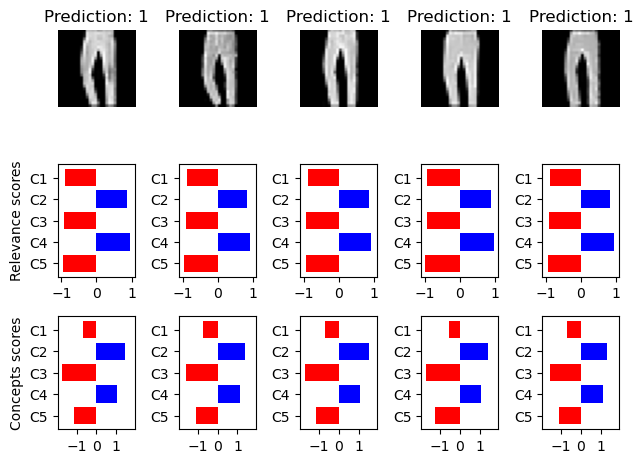

In [62]:
imgs = torch.stack([test_loader.dataset[index][0] for index in image_indices])

fig = get_comparison_plot(imgs, trainer.model)
fig.tight_layout()

## Concept visualization

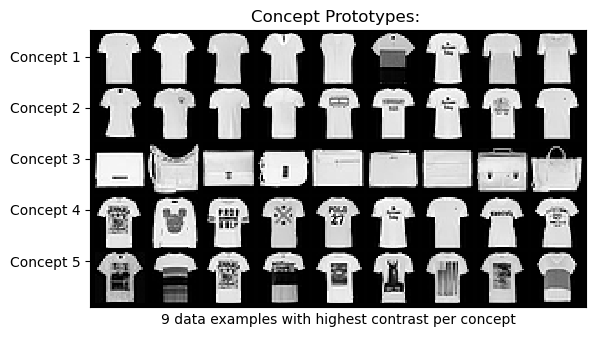

<Figure size 640x480 with 0 Axes>

In [64]:
highest_contrast(
    model=trainer.model, 
    test_loader=test_loader, 
    num_concepts=5,      # Update this if your JSON config uses a different number
    num_prototypes=9,    # Adjust depending on how many examples you want to see
    save_path=None       # Or provide a string path like "concept_prototypes.png"
)

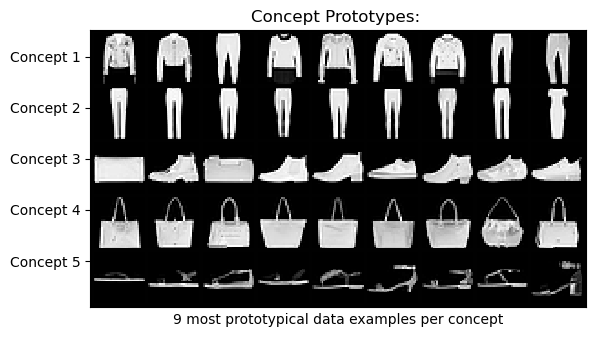

<Figure size 640x480 with 0 Axes>

In [65]:
highest_activations(
    model=trainer.model, 
    test_loader=test_loader, 
    num_concepts=5,      # Update this if your JSON config uses a different number
    num_prototypes=9,    # Adjust depending on how many examples you want to see
    save_path=None       # Or provide a string path like "concept_prototypes.png"
)